# Preliminary

In [1]:
# BiocManager::install('GenomeInfoDbData')
library(dplyr)
library(tidyr)
library(nanoparquet)
library(ggplot2)
library(gprofiler2)
library(easylift)
library(purrr)
library(slider)
library(cowplot)
library(svglite)

fig_size <- function(width, heigth){
 options(repr.plot.width = width, repr.plot.height = heigth)
}

lift_hg19_to_hg38 = function(df) {
    if (!('chr' %in% names(df))) stop('df must have a column named chr')
    if (!('start' %in% names(df) && 'end' %in% names(df)) && 'pos' %in% names(df)) {
        df$start = df$end = as.numeric(df$pos)
    } else if (!('start' %in% names(df) && 'end' %in% names(df)) && 'bp' %in% names(df)) {
        df$start = df$end = as.numeric(df$bp)
    } else if (!('start' %in% names(df) && 'end' %in% names(df))) {
        stop('df must have columns named start and end or pos or bp')
    }

    # If chr is not a string or does not start with 'chr', add 'chr' to the beginning
    if (class(df$chr) != 'character' || !all(grepl('^chr', df$chr))) df$chr = paste0('chr', df$chr)

    hg19 = GenomicRanges::makeGRangesFromDataFrame(df, keep.extra.columns=T, ignore.strand=T)
    genome(hg19) = 'hg19'

    chain = '/Users/noah/data/liftover/hg19ToHg38.over.chain' # Note that this cannot be gzipped
    hg38 = easylift::easylift(hg19, to='hg38', chain)

    out = data.frame(hg38)
    if ('pos' %in% names(out)) out$pos = out$end
    if ('bp' %in% names(out)) out$bp = out$end
    out = out %>% dplyr::rename(chr=seqnames) %>% dplyr::select(-width, -strand)
    return(out)
}

lift_hg38_to_hg19 = function(df) {
    if (!('chr' %in% names(df))) stop('df must have a column named chr')
    if (!('start' %in% names(df) && 'end' %in% names(df)) && 'pos' %in% names(df)) {
        df$start = df$end = as.numeric(df$pos)
    } else if (!('start' %in% names(df) && 'end' %in% names(df)) && 'bp' %in% names(df)) {
        df$start = df$end = as.numeric(df$bp)
    } else if (!('start' %in% names(df) && 'end' %in% names(df))) {
        stop('df must have columns named start and end or pos or bp')
    }

    # If chr is not a string or does not start with 'chr', add 'chr' to the beginning
    if (class(df$chr) != 'character' || !all(grepl('^chr', df$chr))) df$chr = paste0('chr', df$chr)

    hg38 = GenomicRanges::makeGRangesFromDataFrame(df, keep.extra.columns=T, ignore.strand=T)
    genome(hg38) = 'hg38'

    chain = '/Users/noah/data/liftover/hg38ToHg19.over.chain' # Note that this cannot be gzipped
    hg19 = easylift::easylift(hg38, to='hg19', chain)

    out = data.frame(hg19)
    if ('pos' %in% names(out)) out$pos = out$end
    if ('bp' %in% names(out)) out$bp = out$end
    out = out %>% dplyr::rename(chr=seqnames) %>% dplyr::select(-width, -strand) #dplyr::select(-start, -end, -strand, -width)
    return(out)
}

lift_pig_positions_to_hg38 = function(df) {
    if (!('chr' %in% names(df))) stop('df must have a column named chr')
    if (!('start' %in% names(df) && 'end' %in% names(df)) && 'pos' %in% names(df)) {
        df$start = df$end = as.numeric(df$pos)
    } else if (!('start' %in% names(df) && 'end' %in% names(df)) && 'bp' %in% names(df)) {
        df$start = df$end = as.numeric(df$bp)
    } else if (!('start' %in% names(df) && 'end' %in% names(df))) {
        stop('df must have columns named start and end or pos or bp')
    }

    # If chr is not a string or does not start with 'chr', add 'chr' to the beginning
    if (class(df$chr) != 'character' || !all(grepl('^chr', df$chr))) df$chr = paste0('chr', df$chr)

    susscr11 = GenomicRanges::makeGRangesFromDataFrame(df, keep.extra.columns=T, ignore.strand=T)
    genome(susscr11) = 'susScr11'

    chain = '/Users/noah/data/liftover/susScr11ToHg38.over.chain' # Note that this cannot be gzipped
    hg38 = easylift::easylift(susscr11, to='hg38', chain)

    out = data.frame(hg38)
    if ('pos' %in% names(out)) out$pos = out$end
    if ('bp' %in% names(out)) out$bp = out$end
    out = out %>% dplyr::rename(chr=seqnames) %>% dplyr::select(-width, -strand) #dplyr::select(-start, -end, -strand, -width)
    return(out)
}

lift_susScr11_to_hg38 = function(df) {
    if (class(df$chr) != 'character' || !all(grepl('^chr', df$chr))) df$chr = paste0('chr', df$chr)

    susScr11 = GenomicRanges::makeGRangesFromDataFrame(df, keep.extra.columns=T, ignore.strand=T)
    genome(susScr11) = 'susScr11'
    chain = '~/data/liftover/susScr11ToHg38.over.chain'  # Note that this cannot be gzipped
    hg38 = easylift::easylift(susScr11, to='hg38', chain)
    
    out = data.frame(hg38)
    out = out %>% mutate(chr=as.character(seqnames)) %>% select(-seqnames, -width, -strand) %>% relocate(chr)
    return(out)
}


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, intersect, is.unsorted,
    lapply, mapply, match, mget, order, paste, pmax, pmax.int, pmin,
    pmin.int, rank, rbind, rownames, sapply, setdiff, sort, table,
    tapply, union, unique, unsplit, which.max, which.min


Loading

# *EEF2* info

In [12]:
h_eef2_id = 'ENSG00000167658'
h_eef2_bounds = c(3976056, 3985463) # On chromosome 19

Data were fat-free body mass (as measured by impedance), downloaded from Pan-UK Biobank ([download here](https://pan-ukb-us-east-1.s3.amazonaws.com/sumstats_flat_files/continuous-23101-both_sexes-irnt.tsv.bgz)).

I've extracted the region within 1 Mb of EEF2's bounds (listed above) just to read in more quickly.

And muscle tissue from human GTEx version ([download from a google requester-pays bucket](https://console.cloud.google.com/storage/browser/gtex-resources)).

In [ ]:
h_full_imped_hg19 = read.table('~/comparative_colocalization/data/eef2_fig/human/full_imped_chr19.tsv.gz', header=T, as.is=T)
h_full_imped = lift_hg19_to_hg38(h_full_imped_hg19)

hmuscle19 = read_parquet('~/comparative_colocalization/data/eef2_fig/human/GTEx_Analysis_v8_QTLs_GTEx_Analysis_v8_EUR_eQTL_all_associations_Muscle_Skeletal.v8.EUR.allpairs.chr19.parquet') %>%
    filter(stringr::str_detect(phenotype_id, paste0('^', h_eef2_id))) %>% 
    separate_wider_delim(variant_id, '_', names=c('chr', 'pos', 'a1', 'a2', 'build'), cols_remove=F) %>% mutate(pos=as.numeric(pos))

Pig GWAS data are from [SciDB](https://www.scidb.cn/en/s/ZRjEve).

Pig GTEx data are also from [SciDB](https://www.scidb.cn/en/s/uiABfy)

In [3]:
read_pig_gtex = function(tissue, chr) {
    pgtex = read.table(paste0('/Users/noah/comparative_colocalization/data/eef2_fig/pig/gtex/by_chr/pgtex.', tissue, '.chr', chr, '.tsv'), header=F, as.is=T,
        col.names = c('phenotype_id', 'chr', 'pos', 'a1', 'a2', 'tss_distance', 'af', 'ma_samples', 'ma_count', 'pval_nominal', 'slope', 'slope_se'))
    return(pgtex)
}

# Data are from https://www.scidb.cn/en/s/ZRjEve
read_pig_gwas = function(fname, chr) {
    pgwas = read.table(fname, header=T, as.is=T) %>%
        filter(chromosome == chr) %>% 
        dplyr::rename(chr = chromosome) %>%
        dplyr::rename(pos=position)
    return(pgwas)
}

fname_lmdep = '~/comparative_colocalization/data/eef2_fig/pig/M_LMDEP.txt.gz'
eef2_bounds = c(74747080, 74756680) # on chromosome 2
eef2_id = 'ENSSSCG00000025675'

lmdep2 = read_pig_gwas(fname_lmdep, chr=2)
pmuscle2 = read_pig_gtex('muscle', 2)

PhyloP data were from the Zoonomia Project via [UCSC Table Browser](https://genome.ucsc.edu/cgi-bin/hgTables?hgsid=3328845451_CZoFU2KZ7vyGvhPAcWIgBE9PZoTQ&clade=mammal&org=Human&db=hg38&hgta_group=compGeno&hgta_track=cons447way&hgta_table=phyloP447wayLRT&hgta_regionType=genome&position=chr7%3A155%2C799%2C529-155%2C812%2C871&hgta_outputType=wigData&hgta_outFileName=).

First, select the aligned regions.

In [16]:
pig_region = data.frame(chr=c('chr2'), end=seq(eef2_bounds[1]-5e5,eef2_bounds[2]+1e5))
pig_region$start = pig_region$end - 1
pig_region$orig_pos = pig_region$end
pig_region$species = 'pig'

pig_region_lifted = lift_susScr11_to_hg38(pig_region)
write.table(pig_region_lifted, '~/tmp/pig_eef2_region_hg38.bed', row.names=F, col.names=F)

human_region = data.frame(chr=c('chr19'), end=seq(h_eef2_bounds[1]-0.5e5, h_eef2_bounds[2]+4e5))
human_region$start = human_region$end - 1
human_region$orig_pos = human_region$end
human_region$species = 'human'

regions_for_phylop = rbind(pig_region_lifted, human_region) %>% select(chr, start, end, orig_pos, species)
write.table(regions_for_phylop, '~/tmp/regions_for_phylop.bed', row.names=F, col.names=F, quote=F, sep='\t')

eef2_scores = read.table('~/comparative_colocalization/data/phylop/scores/eef2_region_phylop.bed', col.names=c('chr', 'start', 'end', 'id', 'score')) %>% select(-id)
pig_region_lifted = pig_region_lifted %>% left_join(eef2_scores)
human_region = human_region %>% left_join(eef2_scores)

Joining with `by = join_by(chr, start, end)`
Joining with `by = join_by(chr, end, start)`


Using a tool of your choice (bedtools, awk, etc.), remove these regions from the PhyloP data. This is mostly to save space and not have to download all PhyloP data. 

Then take a sliding window that measures what portion of positions are conserved in the region. Note that
- This is looking at all positions, not just positions that have variants
- The cutoff (taken from Zoonomia) for conservation is PhyloP > 2.27

In [17]:
human_region2 = read.table('~/comparative_colocalization/data/eef2_fig/eef2_full_region_phylop.bed.gz', col.names=c('chr', 'start', 'orig_pos', 'id', 'score')) %>% select(-id)
human_conserved = human_region2 %>% mutate(conserved = score >= 2.27)
human_conserved$sliding_mean5000 = slide_index_dbl(.x = human_conserved$conserved, .i = human_conserved$orig_pos, .f = ~mean(.x, na.rm=T), .before=2500, .after=2500)

pig_conserved = pig_region_lifted %>% mutate(conserved = score >= 2.27)
pig_conserved$sliding_mean5000 = slide_index_dbl(.x = pig_conserved$conserved, .i = pig_conserved$orig_pos, .f = ~mean(.x, na.rm=T), .before=2500, .after=2500)

# Plots

In [6]:
plot_human_local_lead_ek = function(gwas, gtex, gene_id, gene_bounds, lower_wind, upper_wind, window=100000, gwas_p_cutoff=5e-8, eqtl_p_cutoff=1, rev=TRUE, print_tab=TRUE, return_df=FALSE, remove_intragenic=FALSE) {
    hcomp = inner_join(
        gwas %>% dplyr::select(pos, neglog10_pval_EUR),
        gtex %>% mutate(gene = gsub('\\..*', '', phenotype_id)) %>% filter(gene==gene_id) %>% dplyr::select(pos, tss_distance, maf, pval_nominal),
        by=join_by(pos)
    ) %>%
    filter(pos > gene_bounds[1]-lower_wind, pos < gene_bounds[2]+upper_wind)

    if (remove_intragenic) hcomp = hcomp %>% filter(pos < gene_bounds[1] | pos > gene_bounds[2])

    # Helper functions for local lead tagging
    is_lead_gwas <- function(i, df, window) {
        idx <- which(abs(df$pos[i] - df$pos) <= window)
        max_idx <- idx[which.max(df$neglog10_pval_EUR[idx])]
        return(i == max_idx)
    }
    is_lead_gtex <- function(i, df, window) {
        idx <- which(abs(df$pos[i] - df$pos) <= window)
        min_idx <- idx[which.min(df$pval_nominal[idx])]
        return(i == min_idx)
    }

    hcomp_gwas = hcomp %>%
        mutate(
            lead_gwas = map_lgl(row_number(), ~is_lead_gwas(.x, hcomp, window)),
            lead = case_when(
                neglog10_pval_EUR >= -log10(gwas_p_cutoff) & lead_gwas ~ 'gwas',
                TRUE ~ 'neither'
            )
        )

    hcomp_gtex = hcomp %>%
        mutate(
            lead_gtex = map_lgl(row_number(), ~is_lead_gtex(.x, hcomp, window)),
            lead = case_when(
                pval_nominal <= eqtl_p_cutoff & lead_gtex ~ 'gtex',
                TRUE ~ 'neither'
            )
        )

    hcomp <- hcomp %>%
        mutate(
            lead_gwas = map_lgl(row_number(), ~is_lead_gwas(.x, hcomp, window)),
            lead_gtex = map_lgl(row_number(), ~is_lead_gtex(.x, hcomp, window)),
            lead = case_when(
                neglog10_pval_EUR >= -log10(gwas_p_cutoff) & pval_nominal <= eqtl_p_cutoff & lead_gwas & lead_gtex ~ 'both',
                neglog10_pval_EUR >= -log10(gwas_p_cutoff) & lead_gwas ~ 'gwas',
                pval_nominal <= eqtl_p_cutoff & lead_gtex ~ 'gtex',
                TRUE ~ 'neither'
            )
        )

    if (return_df) return(hcomp %>% filter(lead != 'neither'))
    if (print_tab) print(hcomp %>% filter(lead != 'neither'))

    segment_data = data.frame(y=0, yend=0, x=gene_bounds[1], xend=gene_bounds[2])

    plt1 = ggplot(hcomp_gwas, aes(x=pos, y=neglog10_pval_EUR, shape=lead, size=lead, color=lead)) + geom_point(fill='lightpink1') + theme_classic() +
        scale_shape_manual(values=c('neither'=20, 'gwas'=24, 'gtex'=25, 'both'=15)) + scale_size_manual(values=c('neither'=1, 'gwas'=3, 'gtex'=3, 'both'=3)) +
        scale_color_manual(values=c('neither'='lightpink1', 'gwas'='black', 'gtex'='black', 'both'='lightpink1')) +
        theme(legend.position='none') + ylab(bquote(-log[10](P[GWAS]))) + xlab(element_blank()) +
        annotate('segment', y=0, yend=0, x=gene_bounds[1], xend=gene_bounds[2], color='black', linewidth=4) # Required to work around a bug when using scale_x_reverse and geom_segment
    plt2 = ggplot(hcomp_gtex, aes(x=pos, y=-log10(pval_nominal), shape=lead, size=lead, color=lead)) + geom_point(fill='firebrick1') + theme_classic() + 
        scale_shape_manual(values=c('neither'=20, 'gwas'=24, 'gtex'=25, 'both'=15)) + scale_size_manual(values=c('neither'=1, 'gwas'=3, 'gtex'=3, 'both'=3)) +
        scale_color_manual(values=c('neither'='firebrick1', 'gwas'='black', 'gtex'='black', 'both'='firebrick1')) + 
        theme(legend.position='none') + ylab(bquote(-log[10](P[eQTL]))) + xlab(element_blank()) +
        annotate('segment', y=0, yend=0, x=gene_bounds[1], xend=gene_bounds[2], color='black', linewidth=4) + # Required to work around a bug when using scale_x_reverse and geom_segment
        scale_y_reverse()

    if (rev) {
        plt1 = plt1 + scale_x_continuous(trans='reverse')
        plt2 = plt2 + scale_x_continuous(trans='reverse', position='top')
    } else {
        # plt1 = plt1 + scale_x_continuous(position='top')
        plt2 = plt2 + scale_x_continuous(position='top')
    }

    return(list(plt1, plt2))

    # print(plt1)
    # print(plt2)
}


plot_pig_local_lead_ek = function(gwas, gtex, gene_id, gene_bounds, lower_wind, upper_wind, window=100000, gwas_p_cutoff=5e-8, rev=FALSE, eqtl_p_cutoff=1, print_tab=TRUE, return_df=FALSE) {
    pcomb = inner_join(
        gwas,
        gtex %>% mutate(gene = gsub('\\..*', '', phenotype_id)) %>% filter(gene==gene_id),
        by=join_by(pos)
    ) %>%
    filter(pos > gene_bounds[1]-lower_wind, pos < gene_bounds[2]+upper_wind)

    # Helper functions for local lead tagging
    is_lead_gwas = function(i, df, window) {
        idx = which(abs(df$pos[i] - df$pos) <= window)
        max_idx = idx[which.min(df$p_value[idx])] # Lower p_value is more significant
        return(i == max_idx)
    }
    is_lead_gtex = function(i, df, window) {
        idx <- which(abs(df$pos[i] - df$pos) <= window)
        min_idx <- idx[which.min(df$pval_nominal[idx])]
        return(i == min_idx)
    }

    pcomb_gwas = pcomb %>%
        mutate(
            lead_gwas = map_lgl(row_number(), ~is_lead_gwas(.x, pcomb, window)),
            lead = case_when(
                p_value <= gwas_p_cutoff & lead_gwas ~ 'gwas',
                TRUE ~ 'neither'
            )
        )

    pcomb_gtex = pcomb %>%
        mutate(
            lead_gtex = map_lgl(row_number(), ~is_lead_gtex(.x, pcomb, window)),
            lead = case_when(
                pval_nominal <= eqtl_p_cutoff & lead_gtex ~ 'gtex',
                TRUE ~ 'neither'
            )
        )

    pcomb = pcomb %>%
        mutate(
            lead_gwas = map_lgl(row_number(), ~is_lead_gwas(.x, pcomb, window)),
            lead_gtex = map_lgl(row_number(), ~is_lead_gtex(.x, pcomb, window)),
            lead = case_when(
                p_value <= gwas_p_cutoff & pval_nominal <= eqtl_p_cutoff & lead_gwas & lead_gtex ~ 'both',
                p_value <= gwas_p_cutoff & lead_gwas ~ 'gwas',
                pval_nominal <= eqtl_p_cutoff & lead_gtex ~ 'gtex',
                TRUE ~ 'neither'
            )
        )

    if (return_df) return(pcomb %>% filter(lead != 'neither'))
    if (print_tab) print(pcomb %>% filter(lead != 'neither'))

    plt1 = ggplot(pcomb_gwas, aes(x=pos, y=-log10(p_value), shape=lead, size=lead, color=lead)) + geom_point(fill='skyblue1') + theme_classic() +
        theme(legend.position='none') + scale_shape_manual(values=c('neither'=20, 'gwas'=24, 'gtex'=25, 'both'=15)) +
        scale_size_manual(values=c('neither'=1, 'gwas'=3, 'gtex'=3, 'both'=3)) +
        scale_color_manual(values=c('neither'='skyblue1', 'gwas'='black', 'gtex'='black', 'both'='black')) +
        # geom_segment(y=0, yend=0, x=gene_bounds[1], xend=gene_bounds[2], color='black', linewidth=3) +
        annotate('segment', y=0, yend=0, x=gene_bounds[1], xend=gene_bounds[2], color='black', linewidth=4) + # Required to work around a bug when using scale_x_reverse and geom_segment
        xlab(element_blank()) + ylab(bquote(-log[10](P[GWAS])))

    plt2 = ggplot(pcomb_gtex, aes(x=pos, y=-log10(pval_nominal), shape=lead, size=lead, color=lead)) + geom_point(fill='royalblue1') + theme_classic() +
        theme(legend.position='none') + scale_shape_manual(values=c('neither'=20, 'gwas'=24, 'gtex'=25, 'both'=15)) +
        scale_size_manual(values=c('neither'=1, 'gwas'=3, 'gtex'=3, 'both'=3)) +
        scale_color_manual(values=c('neither'='royalblue1', 'gwas'='black', 'gtex'='black', 'both'='black')) +
        # geom_segment(y=0, yend=0, x=gene_bounds[1], xend=gene_bounds[2], color='black', linewidth=3) +
        annotate('segment', y=0, yend=0, x=gene_bounds[1], xend=gene_bounds[2], color='black', linewidth=4) + # Required to work around a bug when using scale_x_reverse and geom_segment
        scale_y_reverse() + xlab(element_blank()) + ylab(bquote(-log[10](P[eQTL]))) + scale_x_continuous(position='top')
    
    if (rev) {
        plt1 = plt1 + scale_x_continuous(trans='reverse')
        plt2 = plt2 + scale_x_continuous(trans='reverse', position='top')
    }

    return(list(plt1, plt2))

    # print(plt1)
    # print(plt2)
}

      pos neglog10_pval_EUR tss_distance       maf pval_nominal lead_gwas
1 4028785            0.8752        43316 0.2602041 3.358694e-05     FALSE
2 4453328           13.5300       467859 0.4523810 2.946392e-01      TRUE
  lead_gtex lead
1      TRUE gtex
2     FALSE gwas


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Warning message:
“Removed 42 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 123944 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 41 rows containing missing values or values outside the scale range
(`geom_point()`).”


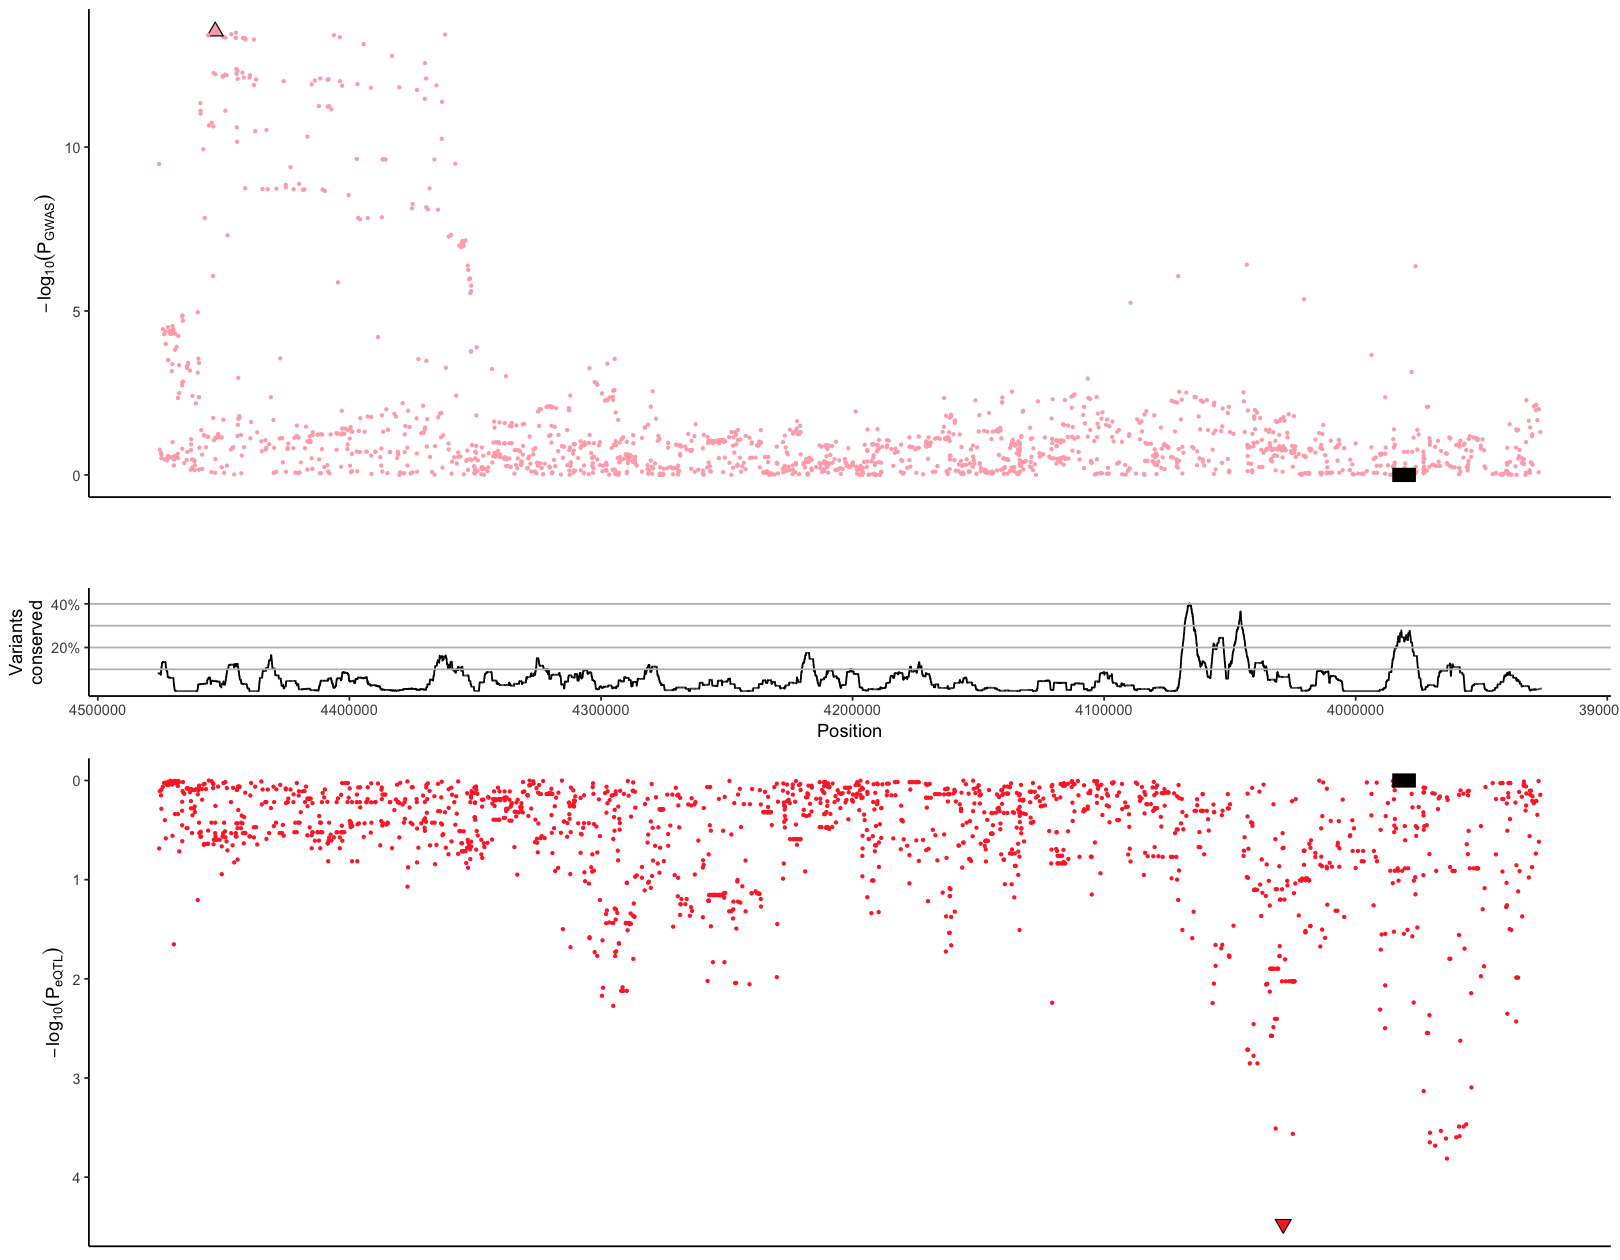

In [18]:
human_plots = plot_human_local_lead_ek(h_full_imped, hmuscle19, gene_id=h_eef2_id, gene_bounds=h_eef2_bounds, lower_wind=0.5e5, upper_wind=5e5, window=1e5, eqtl_p_cutoff=1e-3, print_tab=T)
h1 = human_plots[[1]] + theme(axis.title.x=element_blank(), axis.text.x=element_blank(), axis.ticks.x=element_blank()) + xlim(h_eef2_bounds[1]-0.5e5, h_eef2_bounds[1]+5e5) # + geom_vline(xintercept=4453328, color='black', linetype='dotted')
h2 = human_plots[[2]] + theme(axis.title.x=element_blank(), axis.text.x=element_blank(), axis.ticks.x=element_blank()) + xlim(h_eef2_bounds[1]-0.5e5, h_eef2_bounds[1]+5e5) # + geom_vline(xintercept=4028785, color='black', linetype='dotted')

h_cons = ggplot(human_conserved, aes(x=orig_pos, y=sliding_mean5000)) + geom_line() + theme_classic() + xlim(h_eef2_bounds[1]-0.5e5, h_eef2_bounds[1]+5e5) + scale_x_reverse() + scale_y_continuous(breaks=c(0.2, 0.4), labels=c('20%', '40%'), limits=c(0, 0.45)) + xlab('Position') + ylab('Variants\nconserved') + 
    geom_hline(yintercept=0.1, color='gray', linewidth=0.5) + geom_hline(yintercept=0.2, color='gray', linewidth=0.5) + geom_hline(yintercept=0.3, color='gray', linewidth=0.5) + geom_hline(yintercept=0.4, color='gray', linewidth=0.5)

fig_size(13.5, 10.5)
hplot4 = plot_grid(h1 + scale_x_reverse(limits=c(h_eef2_bounds[1]+5e5, h_eef2_bounds[1]-0.5e5)), NULL, h_cons + scale_x_reverse(limits=c(h_eef2_bounds[1]+5e5, h_eef2_bounds[1]-0.5e5)), h2 + scale_x_reverse(limits=c(h_eef2_bounds[1]+5e5, h_eef2_bounds[1]-0.5e5)), align='v', axis='lr', ncol=1, rel_heights=c(3, 0.4, 1, 3)) + panel_border(remove=T, color='white')
hplot4
# save_plot('~/comparative_colocalization/data/eef2_fig/human_fig.png', hplot4, ncol=1, nrow=4, base_height=2, base_width=9)

  chr.x      pos reference_allele alternate_allele   p_value sample_size
1     2 74285561                C                T 1.311e-06       28750
2     2 74315322                G                C 8.264e-12       22370
3     2 74489541                T                C 6.102e-10       25942
4     2 74501210                T                C 5.245e-01         942
5     2 74643781                A                G 2.698e-11       25942
6     2 74678968                G                C 8.741e-01         942
7     2 74748934                G                A 3.804e-13       26298
        phenotype_id chr.y a1 a2 tss_distance         af ma_samples ma_count
1 ENSSSCG00000025675     2  T  C      -461519 0.18584406        415      491
2 ENSSSCG00000025675     2  C  G      -431758 0.18508705        415      489
3 ENSSSCG00000025675     2  C  T      -257539 0.15404996        353      407
4 ENSSSCG00000025675     2  C  T      -245870 0.05109765        111      135
5 ENSSSCG00000025675     2  G  

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Warning message:
“Removed 19 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 20851 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 19 rows containing missing values or values outside the scale range
(`geom_point()`).”


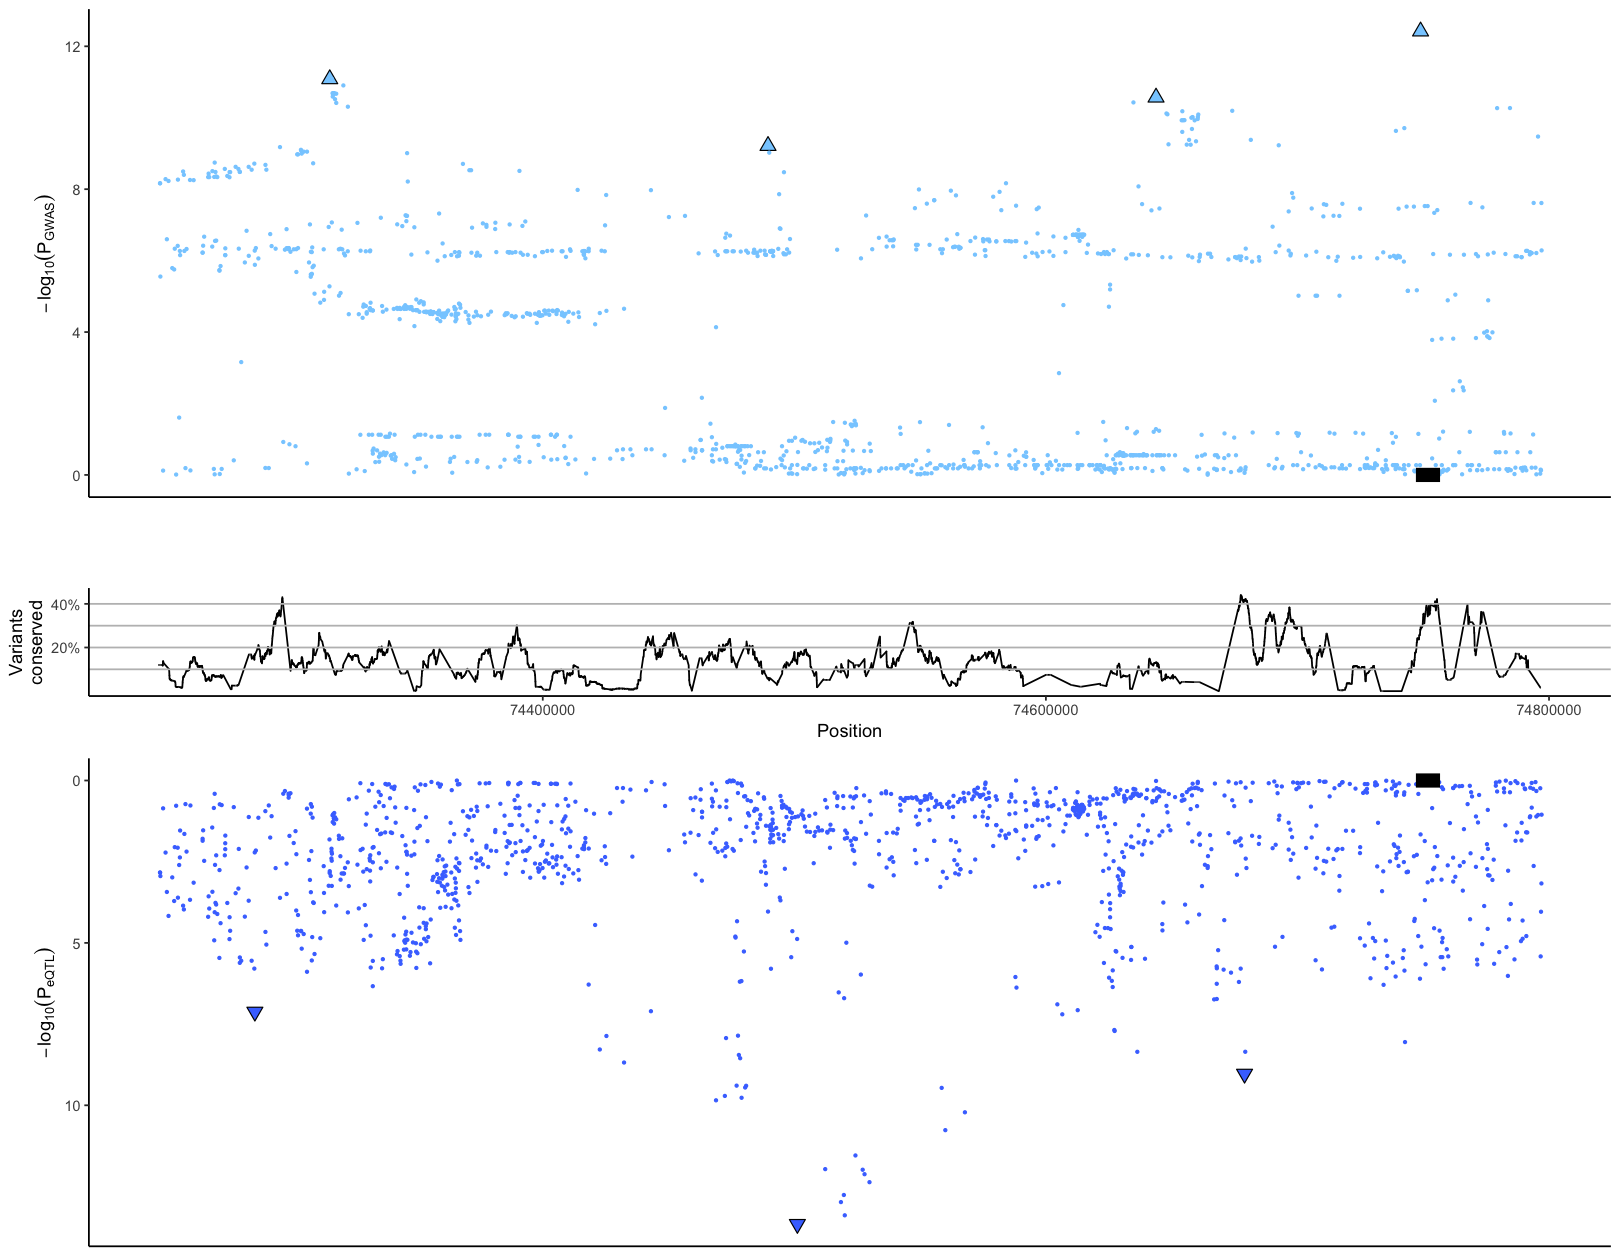

In [19]:
pig_plots = plot_pig_local_lead_ek(lmdep2, pmuscle2, gene_id=eef2_id, gene_bounds=eef2_bounds, lower_wind=5e5, upper_wind=0.5e5, window=1e5, gwas_p_cutoff=5e-8, eqtl_p_cutoff=0.01, print_tab=T) # + geom_vline(xintercept=74297508)
p1 = pig_plots[[1]] + theme(axis.title.x=element_blank(), axis.text.x=element_blank(), axis.ticks.x=element_blank()) + xlim(eef2_bounds[1]-5e5, eef2_bounds[1]+0.5e5) # + geom_vline(xintercept=74315322, color='black', linetype='dotted') + geom_vline(xintercept=74489541, color='black', linetype='dotted')
p2 = pig_plots[[2]] + theme(axis.title.x=element_blank(), axis.text.x=element_blank(), axis.ticks.x=element_blank()) + xlim(eef2_bounds[1]-5e5, eef2_bounds[1]+0.5e5) # + geom_vline(xintercept=74285561, color='black', linetype='dotted') + geom_vline(xintercept=74501210, color='black', linetype='dotted')
p_cons = ggplot(pig_conserved, aes(x=orig_pos, y=sliding_mean5000)) + geom_line() + theme_classic() + xlim(eef2_bounds[1]-5e5, eef2_bounds[1]+0.5e5) + scale_y_continuous(breaks=c(0.2, 0.4), labels=c('20%', '40%'), limits=c(0, 0.45)) + ylab('Variants\nconserved') + xlab('Position') + 
    geom_hline(yintercept=0.1, color='gray', linewidth=0.5) + geom_hline(yintercept=0.2, color='gray', linewidth=0.5) + geom_hline(yintercept=0.3, color='gray', linewidth=0.5) + geom_hline(yintercept=0.4, color='gray', linewidth=0.5)

fig_size(13.5, 10.5)
pplot4 = plot_grid(p1, NULL, p_cons, p2, align='v', axis='lr', ncol=1, rel_heights=c(3, 0.4, 1, 3))
pplot4
# save_plot('~/comparative_colocalization/data/eef2_fig/pig_fig.png', pplot4, ncol=1, nrow=4, base_height=2, base_width=9)

The connecting dotted lines in Figure 4 were added manually.